In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Data Load**

In [2]:
df = pd.read_csv('cognitive_assessment_demo_750.csv')
df.head(5)

,Age,Education_Years,Memory_Score,Attention_Score,Reaction_Time_ms,Orientation_Score,Daily_Activity_Score,Cognitive_Status
0,67,15,63,63,614,68,61,1
1,75,9,93,91,572,93,65,0
2,60,10,71,77,493,82,76,0
3,65,9,70,75,647,88,74,0
4,82,17,68,54,777,64,70,1


# **Data check**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Age                   750 non-null    int64
 1   Education_Years       750 non-null    int64
 2   Memory_Score          750 non-null    int64
 3   Attention_Score       750 non-null    int64
 4   Reaction_Time_ms      750 non-null    int64
 5   Orientation_Score     750 non-null    int64
 6   Daily_Activity_Score  750 non-null    int64
 7   Cognitive_Status      750 non-null    int64
dtypes: int64(8)
memory usage: 47.0 KB


In [4]:
df.isnull().sum()

,0
Age,0
Education_Years,0
Memory_Score,0
Attention_Score,0
Reaction_Time_ms,0
Orientation_Score,0
Daily_Activity_Score,0
Cognitive_Status,0


In [5]:
df.shape

(750, 8)

In [6]:
df.describe()

,Age,Education_Years,Memory_Score,Attention_Score,Reaction_Time_ms,Orientation_Score,Daily_Activity_Score,Cognitive_Status
count,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000
mean,75.333333,10.661333,70.696000,72.648000,645.788000,80.828000,76.277333,0.222667
std,9.415542,3.092257,10.998889,10.729286,100.638982,8.996277,10.857882,0.416314
min,60.000000,4.000000,33.000000,46.000000,356.000000,53.000000,44.000000,0.000000
25%,67.000000,9.000000,64.000000,65.000000,572.250000,74.000000,69.000000,0.000000
50%,76.000000,11.000000,71.000000,72.000000,647.000000,81.000000,76.000000,0.000000
75%,84.000000,13.000000,78.000000,80.000000,716.750000,87.000000,84.000000,0.000000
max,90.000000,18.000000,100.000000,100.000000,976.000000,100.000000,100.000000,1.000000


In [7]:
df.duplicated().sum()

np.int64(0)

# **EDA**

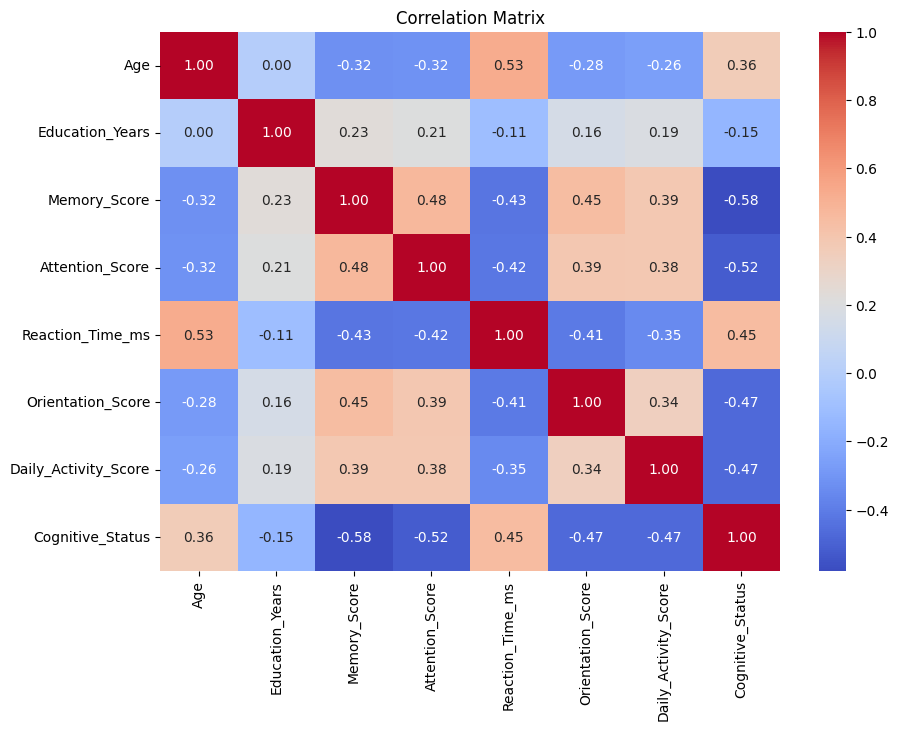

In [8]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [9]:
df["Cognitive_Status"].value_counts()

,count
Cognitive_Status,
0,583
1,167


In [10]:
df["Cognitive_Status"].value_counts(normalize=True) * 100

,proportion
Cognitive_Status,
0,77.733333
1,22.266667


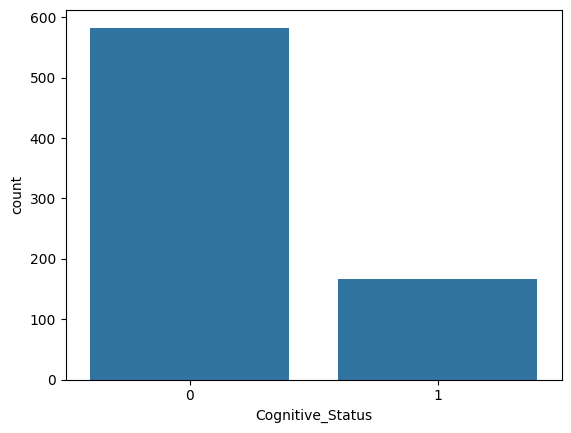

In [11]:
sns.countplot(x="Cognitive_Status", data=df)
plt.show()

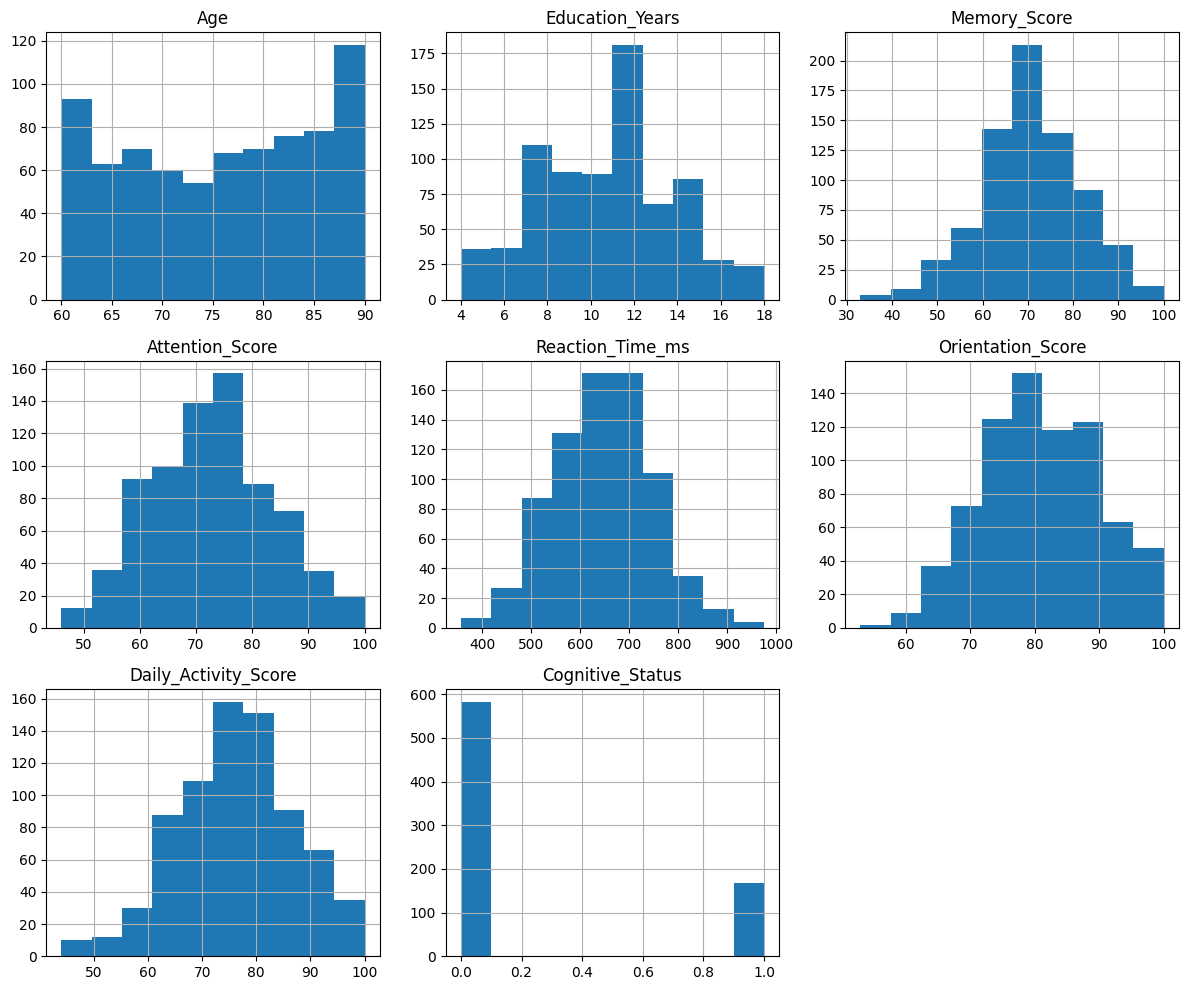

In [12]:
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

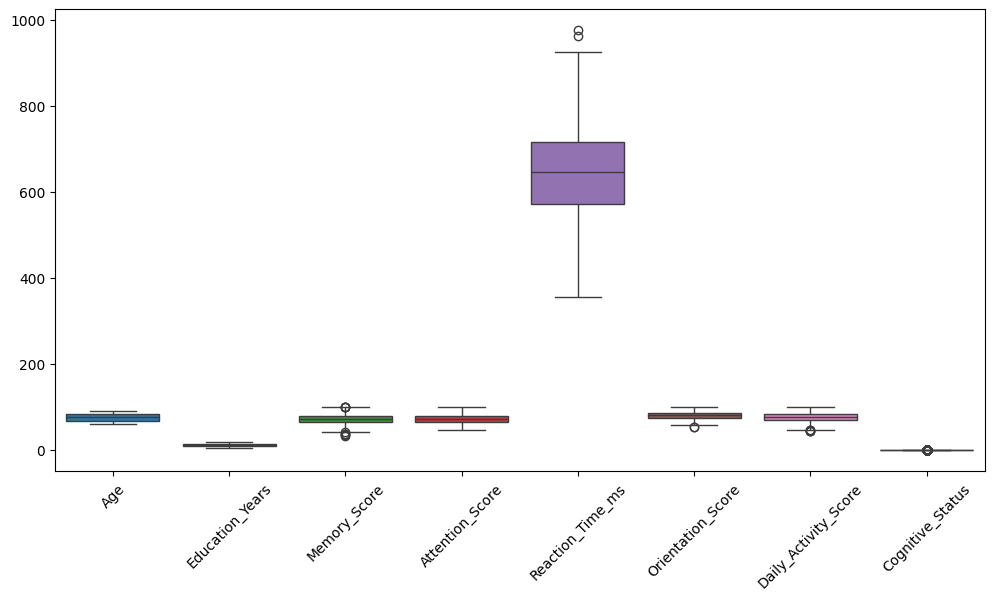

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

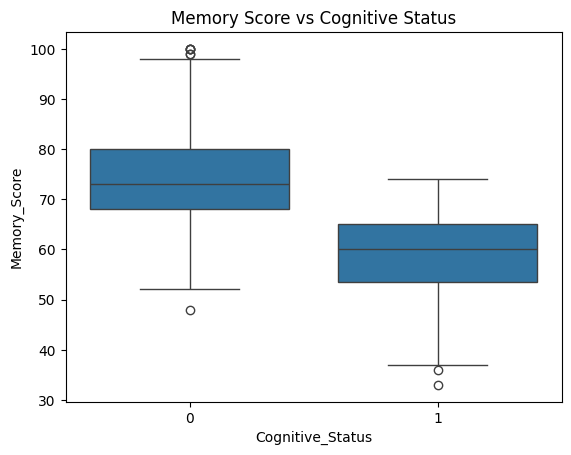

In [14]:
sns.boxplot(
    data=df,
    x="Cognitive_Status",
    y="Memory_Score"
)

plt.title("Memory Score vs Cognitive Status")
plt.show()

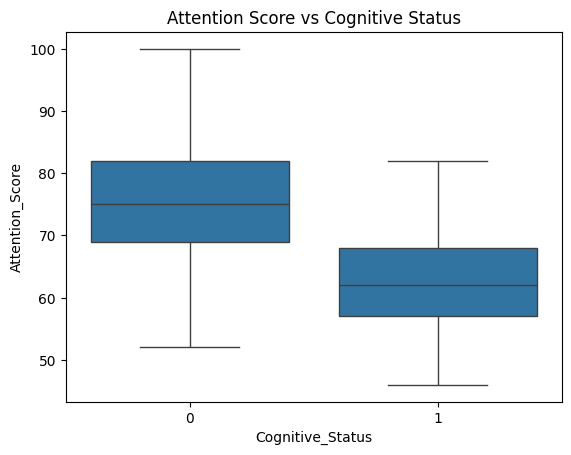

In [15]:
sns.boxplot(
    data=df,
    x="Cognitive_Status",
    y="Attention_Score"
)

plt.title("Attention Score vs Cognitive Status")
plt.show()

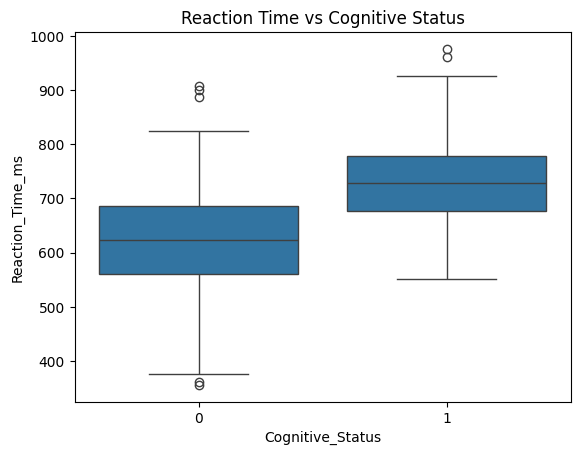

In [16]:
sns.boxplot(
    data=df,
    x="Cognitive_Status",
    y="Reaction_Time_ms"
)

plt.title("Reaction Time vs Cognitive Status")
plt.show()

# **Feature Selection**

In [17]:
X = df.drop(columns=["Cognitive_Status"])
y = df["Cognitive_Status"]

# **Train_Test_Split**

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [19]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [20]:
sc.fit(X)

StandardScaler()

In [21]:
X = pd.DataFrame(sc.transform(X), columns=X.columns)

# **Model_Selection**

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
lr = LogisticRegression()
knn = KNeighborsClassifier(n_neighbors = 5)
dt = DecisionTreeClassifier(criterion= "entropy")
rf = RandomForestClassifier()

In [25]:
lr.fit(X_train, y_train)
knn.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomForestClassifier()

In [29]:
models = {
    'Logistic Regression': lr,
    'K-Nearest Neighbors': knn,
    'Decision Tree': dt,
    'Random Forest': rf
}

for name, model in models.items():
    train_score = model.score(X_train, y_train) * 100
    test_score = model.score(X_test, y_test) * 100
    print(f"{name}:\n  Training Accuracy: {train_score:.2f}%\n  Testing Accuracy: {test_score:.2f}%")

Logistic Regression:
  Training Accuracy: 99.17%
  Testing Accuracy: 98.00%
K-Nearest Neighbors:
  Training Accuracy: 95.33%
  Testing Accuracy: 93.33%
Decision Tree:
  Training Accuracy: 100.00%
  Testing Accuracy: 90.00%
Random Forest:
  Training Accuracy: 100.00%
  Testing Accuracy: 93.33%


In [33]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
cf = confusion_matrix(y_test, lr.predict(X_test))
print(cf)

[[113   1]
 [  2  34]]


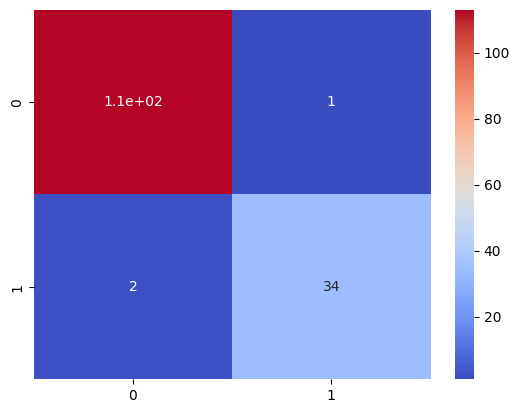

In [34]:
sns.heatmap(cf, annot=True, cmap="coolwarm")
plt.show()

In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       114
           1       0.97      0.94      0.96        36

    accuracy                           0.98       150
   macro avg       0.98      0.97      0.97       150
weighted avg       0.98      0.98      0.98       150



In [38]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    lr,
    X, y,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

CV Scores: [0.98666667 1.         0.98       0.99333333 0.98      ]
Mean CV Accuracy: 0.9879999999999999


In [39]:
import joblib

joblib.dump(lr, "cognitive_assessment_model.joblib")

['cognitive_assessment_model.joblib']